In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph_ref = run["connectivity_map"]
layout = run.cells.to_pandas_dataframe(["umap_1", "umap_2"]).to_numpy()

In [2]:
graph = ds.load_graph(
    graph=graph_ref,
    symmetric=True,
    upper_only=False,
)
graph_strength = np.asarray(graph.sum(axis=1)).ravel()
ds.cells.insert(
    column_name="customGraphStrength",
    values=graph_strength,
    key="I",
    overwrite=True,
)
{
    "cells": int(graph.shape[0]),
    "edges": int(graph.nnz),
    "customGraphStrength mean": float(graph_strength.mean()),
}

{'cells': 3940, 'edges': 64650, 'customGraphStrength mean': 10.034273147583008}

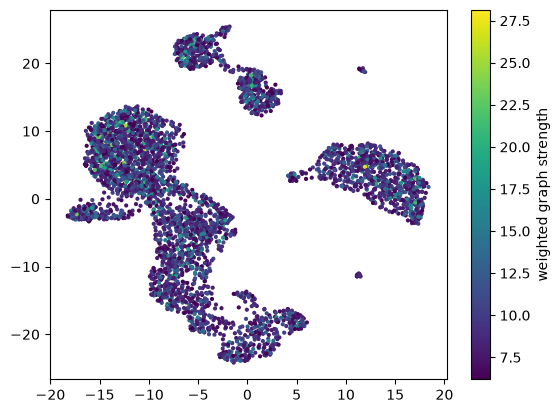

In [3]:
plt.scatter(
    layout[:, 0],
    layout[:, 1],
    c=graph_strength,
    s=4,
)
plt.colorbar(label="weighted graph strength")

In [4]:
cell_index = np.flatnonzero(run.cells.fetch_all("I"))
hvg_values = np.asarray(
    run.features.fetch_all("highly_variable_features"),
    dtype=bool,
)
feature_index = np.flatnonzero(hvg_values)
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

detected_blocks = []
for count_block in selected_counts.stream_blocks(
    nthreads=4,
    msg="Calculating custom detection statistic",
):
    detected_blocks.append(np.count_nonzero(count_block, axis=1))

detected_hvgs = np.concatenate(detected_blocks)
ds.cells.insert(
    column_name="customDetectedHVGs",
    values=detected_hvgs,
    key="I",
    overwrite=True,
)
{
    "cells": int(detected_hvgs.size),
    "customDetectedHVGs mean": float(detected_hvgs.mean()),
    "customDetectedHVGs max": int(detected_hvgs.max()),
}

{'cells': 3940,
 'customDetectedHVGs mean': 137.26700507614214,
 'customDetectedHVGs max': 255}

In [5]:
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)

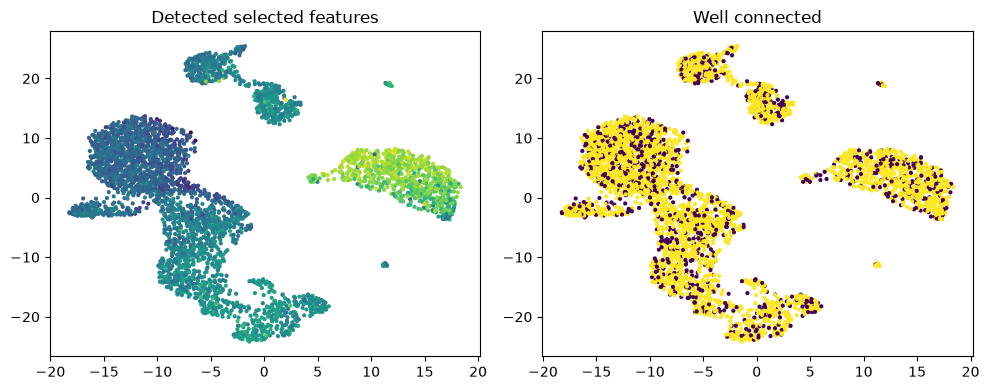

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(layout[:, 0], layout[:, 1], c=detected_hvgs, s=4)
axes[0].set_title("Detected selected features")
axes[1].scatter(layout[:, 0], layout[:, 1], c=well_connected, s=4)
axes[1].set_title("Well connected")
figure.tight_layout()

In [7]:
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
panel_mask = np.isin(feature_names, panel_genes)
custom_features = ds.set_feature_selection(
    mask=panel_mask,
)
custom_features, int(panel_mask.sum())

(ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='f43f77658920...'),
 6)

In [8]:
branch_normalized = ds.run_normalization(
    ds.snapshot_cell_selection(cell_key="wellConnected"),
    custom_features,
)
n_features = int(ds.load_artifact(branch_normalized)["data"].shape[1])
external_loadings = np.eye(n_features, dtype=np.float64)

custom_reduction = ds.run_custom_reduction(
    external_loadings,
    branch_normalized,
)
custom_ann = ds.build_ann_index(custom_reduction)
ds.load_artifact(custom_reduction)["data"].shape, custom_ann

((2955, 6),
 ArtifactRef(assay='RNA', kind='ann_index', artifact_id='ec24de3a9cd6...'))

In [9]:
adata = ds.to_anndata(
    cell_key="wellConnected",
    feature_names=panel_genes,
)
adata.shape, adata.var_names.tolist()

((2955, 6),
 ['ENSG00000167286',
  'ENSG00000156738',
  'ENSG00000170458',
  'ENSG00000090382',
  'ENSG00000105374',
  'ENSG00000115523'])

In [10]:
export_directory = TemporaryDirectory()
subset_path = Path(export_directory.name) / "custom_analyses_subset.zarr"

writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="wellConnected",
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset_ds = scarf.DataStore(str(subset_path))
{
    "source wellConnected cells": int(ds.cells.fetch_all("wellConnected").sum()),
    "subset cells": subset_ds.cells.N,
    "subset RNA features": subset_ds.RNA.feats.N,
}

{'source wellConnected cells': 2955,
 'subset cells': 2955,
 'subset RNA features': 33538}